In [22]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames

In [23]:
using Revise
using Newtrinos
using Newtrinos.osc

In [24]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}(NNM(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 30.0, r = 1.0), (m₀ = Uniform{Float64}(a=1.0e-7, b=0.015), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = Uniform{Float64}(a=3.0, b=100.0), r = Uniform{Float64}(a=0.0, b=1.0)), Newtrinos.osc.var"#get_Nnaturalness#52"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}}(Oscillation

In [25]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

In [26]:
experiments = (

  dayabay= Newtrinos.dayabay.configure(physics),
);

[ Info: Loading dayabay data


In [27]:
p = Newtrinos.get_params(experiments)

(N = 30.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [28]:
using Setfield

In [29]:
# modify the value of m0 with a random value taken from a Distribution

sigma= p.m₀/5
new_m₀_un = rand(Uniform(p.m₀, p.m₀*(1+2/p.r))) 
new_m₀_norm=rand(truncated(Normal(p.m₀,sigma), p.m₀, Inf))
p_new_un = @set p.m₀ = new_m₀_un
p_new_norm = @set p.m₀ =new_m₀_norm


(N = 30.0, m₀ = 0.011822394509440391, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [30]:
assets= experiments.dayabay.assets

(E_arrs = [[1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43], [1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43], [1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43]], L_arrs = [[1919.63, 1917.52, 1925.26, 1894.34, 1891.98, 1899.86, 1533.18, 1534.92, 1538.93, 1533.63, 1535.03, 1539.47, 1551.38, 1554.77, 1556.34, 1524.94, 1528.05, 1530.08], [1919.63, 1917.52, 1925.26, 1923.15, 1894.34, 1891.98, 1899.86, 1897.51, 1533.18, 1534.92  …  1539.47, 1540.87, 1551.38, 1554.77, 1556.34, 1559.72, 1524.94, 1528.05, 1530.08, 1533.18], [1919.63, 1917.52, 1925.26, 1923.15, 1894.34, 1891.98, 1899.86, 1897.51, 1533.18, 1534.92  …  1539.47, 1540.87, 1551.38, 1554.77, 1556.34, 1559.72, 1524.94, 1528.05, 1530.08, 1533.18]], Npred_EH3_nooscs = [[966.99789101819, 1311.4889551891888, 1854.178347329635, 2317.3210980

In [31]:
expected_un = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
expected_un_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))


26-element Vector{Float64}:
 58752.78101265246
 61576.61260715592
 56625.80419131626
 69775.34740415608
 77848.14376410653
 86671.54422250189
 87361.8079647678
 82622.28954021142
 78360.31691859635
 73146.46960170867
 66075.43050564107
 59744.44504966556
 53713.384583731524
 48939.295034744486
 44538.85032969649
 39698.11573740347
 33471.04250431135
 34409.73074105463
 25232.450121158952
 19792.830537529357
 14646.654609000638
  9856.472187177673
  6404.236960351907
  6730.986268855921
  3685.506285063555
 17200.10098411414

In [32]:
expected_norm = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))
expected_norm_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))


26-element Vector{Float64}:
 58748.45639724887
 61505.9068136097
 56517.53466811068
 69600.53830824427
 77680.85770408128
 86580.2204956088
 87245.30586423303
 82629.15378151808
 78456.4501758352
 73206.46361657714
 66106.91627892476
 59821.57663451841
 53839.05430323328
 49010.86153480247
 44667.246532846235
 39801.709539224954
 33515.02951580826
 34505.527073082514
 25288.828658592258
 19828.18226283045
 14667.888699135354
  9881.82348372043
  6410.2436533269265
  6741.477867330914
  3692.245520743134
 17244.683499468993

In [33]:
using CairoMakie

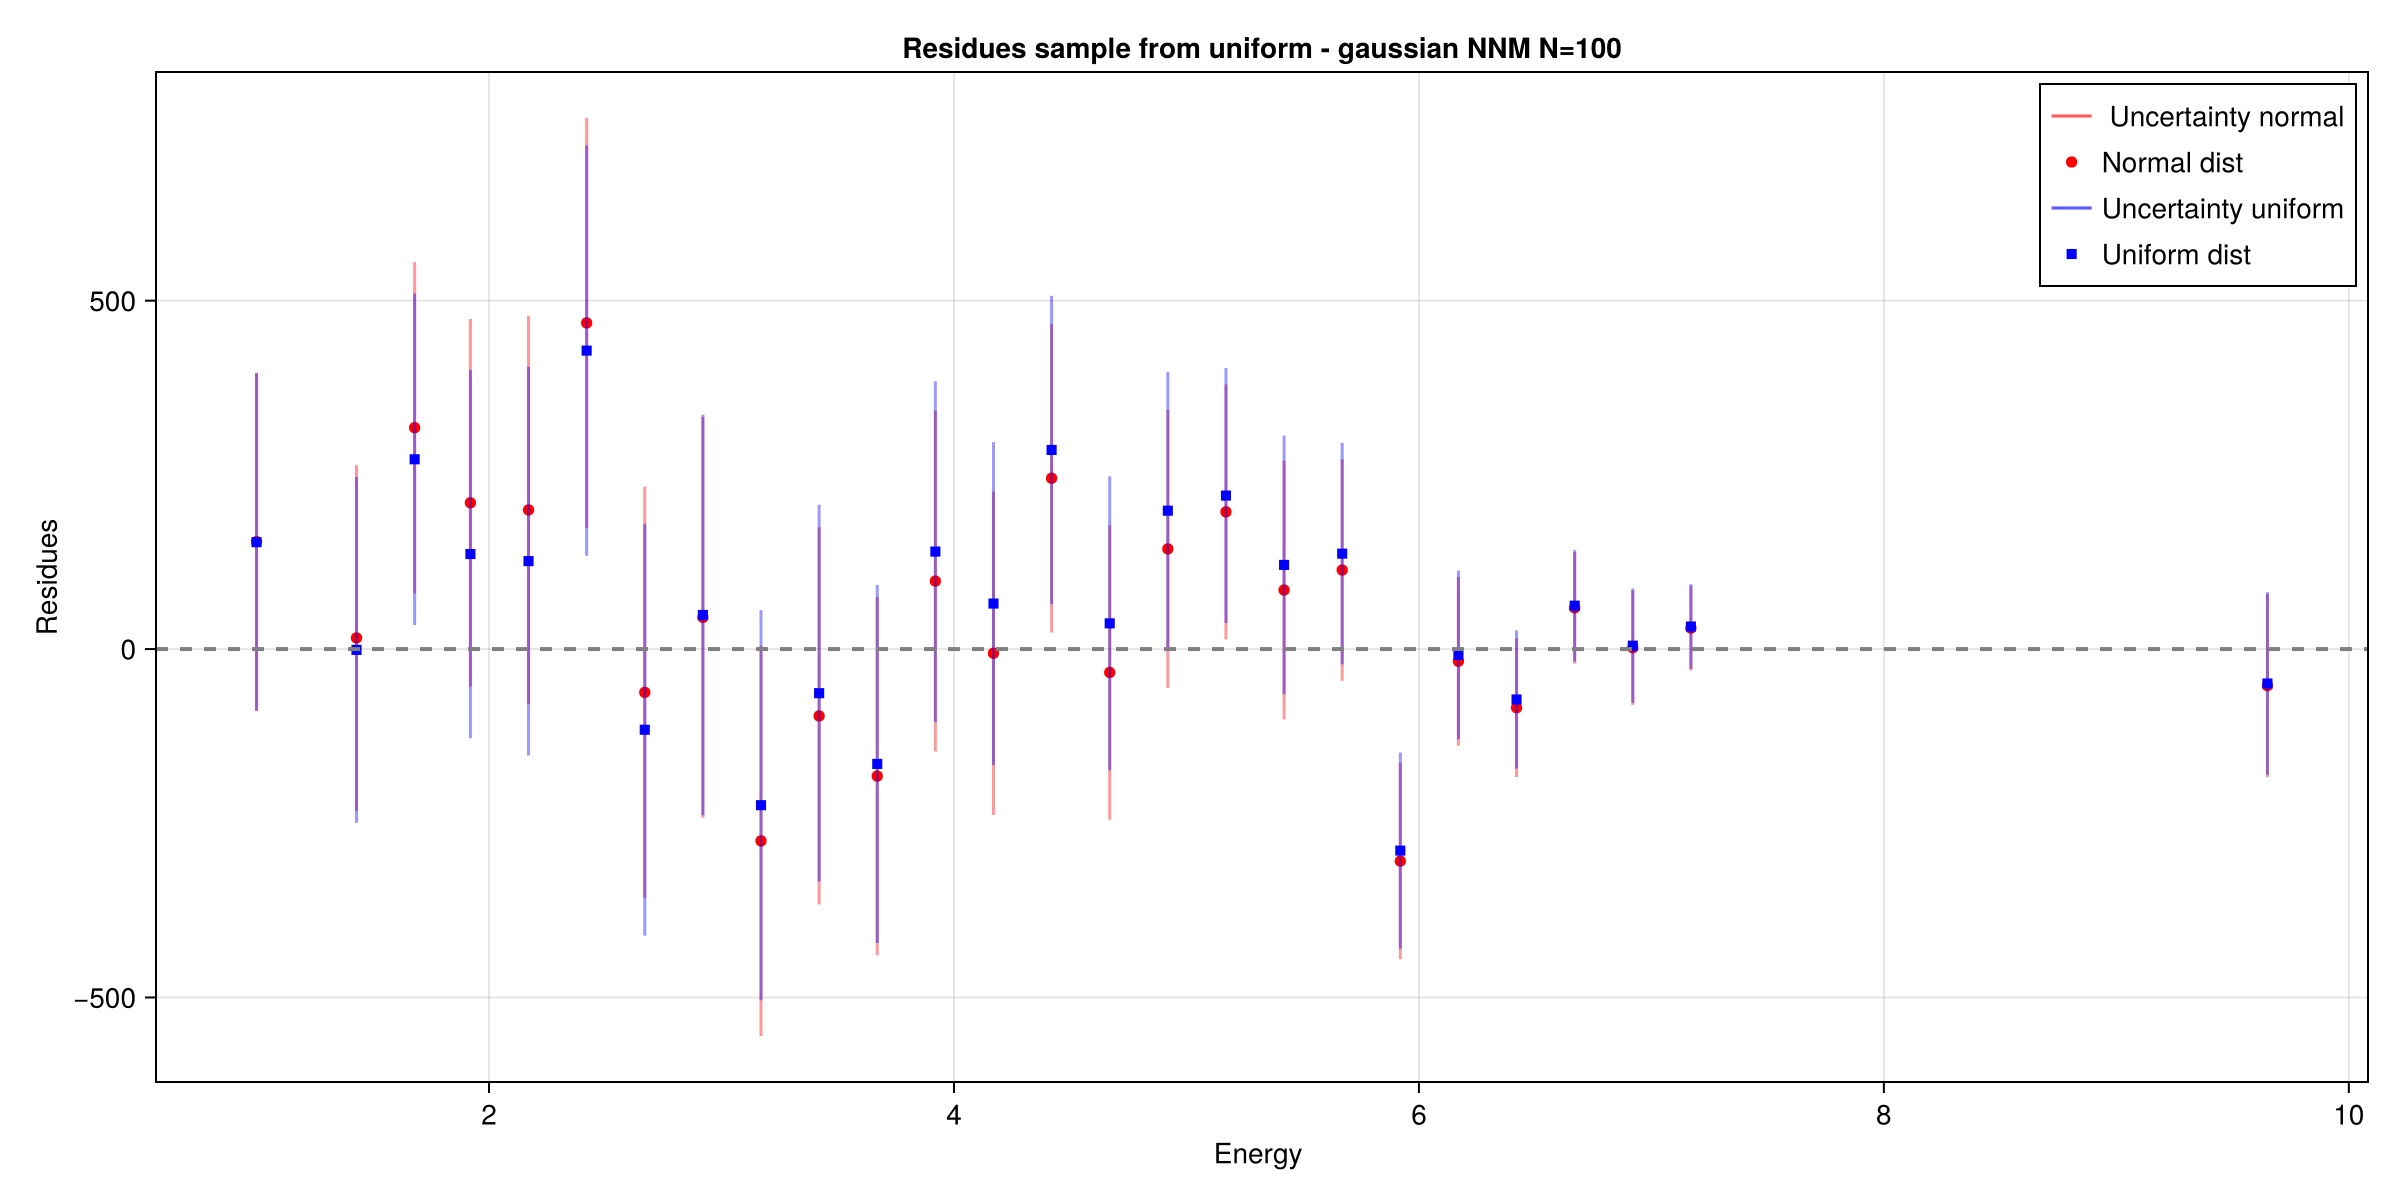

CairoMakie.Screen{IMAGE}


In [34]:

# Create the figure
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "Energy ",
    ylabel = "Residues", 
    title = "Residues sample from uniform - gaussian NNM N=100")


errorbars!(ax, assets.energy,  assets.observed-expected_norm,  sqrt.(expected_norm_var), 
      color = (:red, 0.4), label = " Uncertainty normal")

scatter!(ax, assets.energy,  assets.observed-expected_norm, 
        color = :red, markersize = 8, label = "Normal dist")

errorbars!(ax, assets.energy,  assets.observed-expected_un,sqrt.(expected_un_var), 
      color = (:blue, 0.4), label = "Uncertainty uniform")
      
scatter!(ax, assets.energy, assets.observed-expected_un, 
        color = :blue, marker = :rect, markersize = 8,label = "Uniform dist")

        
# Add a horizontal line at zero for reference
hlines!(ax, [0], color = :gray, linestyle = :dash, linewidth = 2)

    
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/dayabay/nm_dayabay_NNM_N30_residues.png", fig)

In [35]:
#img = experiments.dayabay.plot(p_new_norm)
#display("image/png", img)

In [36]:

using ProgressMeter

In [37]:
function random_sampling(physics, experiments, p)

   chi_squared_un_list = Float64[]
   chi_squared_norm_list = Float64[]

   @showprogress for i in 1:100
      #println("Random sampling iteration: $i")
      sigma=0.000000000000001
      new_m₀_un = rand(Uniform(p.m₀, p.m₀*(1+2/p.r))) 
      new_m₀_norm=rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*(1+2/p.r)))
      p_new_un = @set p.m₀ = new_m₀_un
      p_new_norm = @set p.m₀ =new_m₀_norm

      assets= experiments.dayabay.assets
      observed = assets.observed

      expected_un = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
      expected_un_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
      expected_norm = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))
      expected_norm_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))

      chi_squared_un = sum((observed.- expected_un).^2 ./ expected_un_var)
      chi_squared_norm = sum((observed.- expected_norm).^2 ./ expected_norm_var)

      push!(chi_squared_un_list, chi_squared_un)
      push!(chi_squared_norm_list, chi_squared_norm)

   end
   return chi_squared_un_list, chi_squared_norm_list
end

random_sampling (generic function with 1 method)

In [38]:
trial=random_sampling(physics, experiments, p)

Progress: 100%|█████████████████████████████████████████| Time: 0:06:47


([18.278348421773636, 17.619819098921102, 17.81781604261922, 18.320014949464042, 17.630535166939467, 17.352072366082435, 18.19329503204241, 17.205071133719088, 18.507107084218422, 18.49840777302783  …  17.572423099784064, 18.320977321512622, 17.696171679639793, 17.192649922738347, 17.629551105012315, 16.93066751404331, 17.031251342665215, 17.005150367552947, 17.305594595944743, 17.338372016744877], [17.100892267717125, 17.10089367207501, 17.10089233352587, 17.10089146423724, 17.100893987446707, 17.100891887126295, 17.100892424485284, 17.100890668461354, 17.100892482907124, 17.100893869370154  …  17.100891629611265, 17.10089292024199, 17.100894332440838, 17.10089285605129, 17.10089766951414, 17.100893712023627, 17.100893383526316, 17.100893928288617, 17.100895193912798, 17.100893436257195])

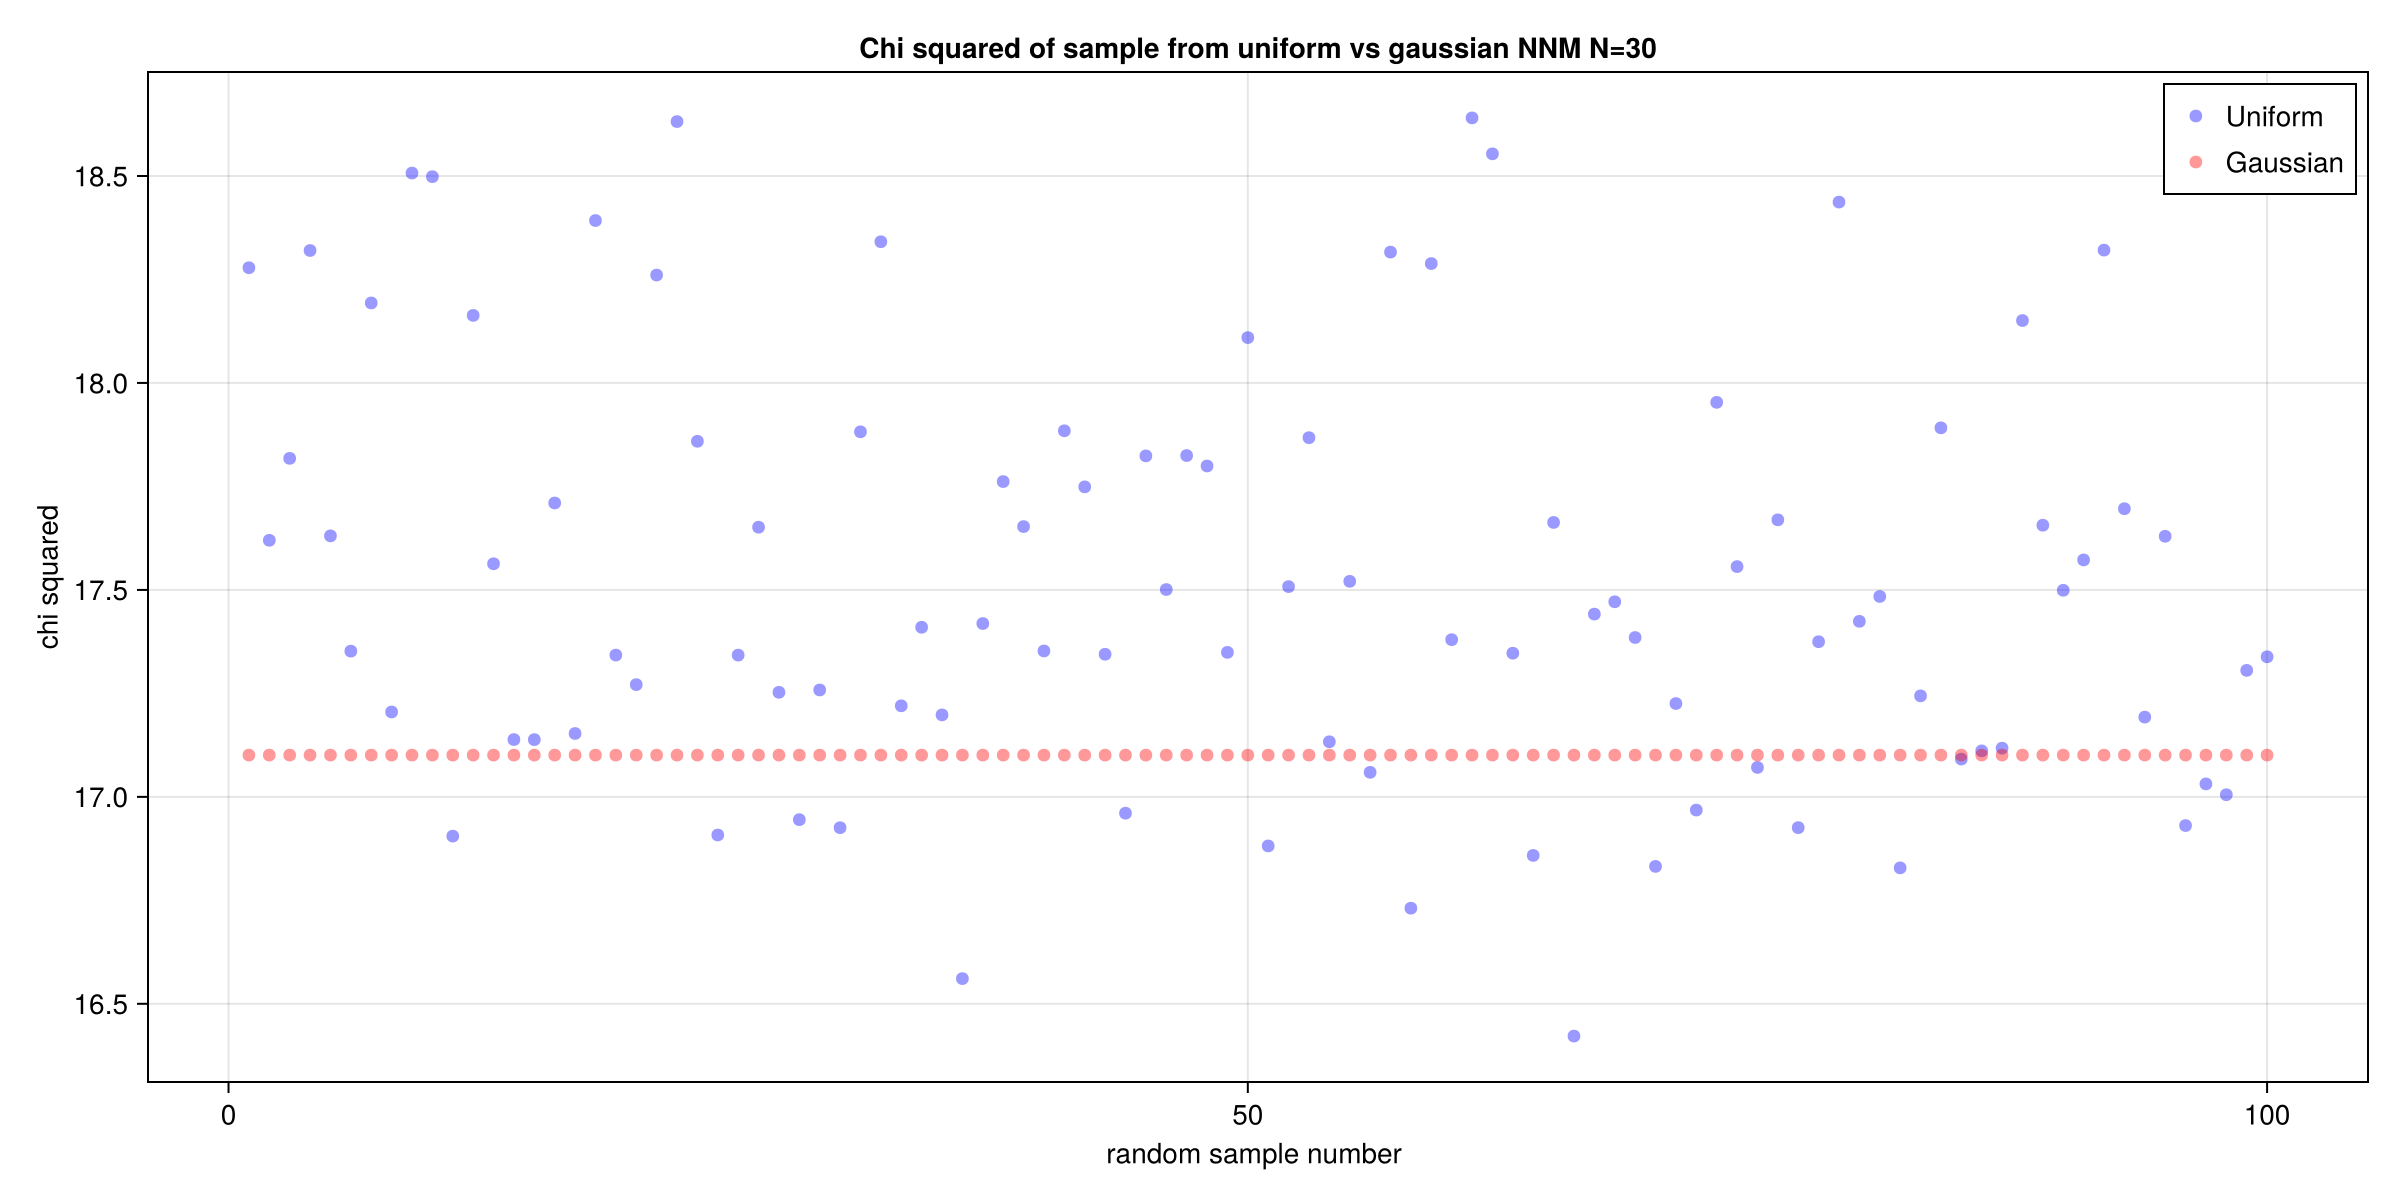

In [39]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "random sample number ",
    ylabel = "chi squared", 
    title = "Chi squared of sample from uniform vs gaussian NNM N=30")
scatter!(ax, 1:100, trial[1], color = (:blue, 0.4), label = "Uniform")
scatter!(ax, 1:100, trial[2], color = (:red, 0.4), label = "Gaussian")

   
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

save("/home/sofialon/Newtrinos.jl/aug_plots/dayabay/nm_dayabay_NNM_N30_m0=0.01_chi.png", fig)